# Set Up

## Mount Google Drive

Ignore if not using Google Collab:

In [1]:
from google.colab import drive

# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive
fatal: destination path 'cooling_with_code' already exists and is not an empty directory.
/content/drive/My Drive/cooling_with_code
Already up to date.


## Import Libraries

In [2]:
%%capture
%pip install stackstac
%pip install pystac-client
%pip install planetary-computer
%pip install odc-stac
%pip install rioxarray
%pip install geopandas
%pip install geopy
%pip install folium

In [87]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Import common GIS tools
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rio
import rasterio
from matplotlib.cm import RdYlGn,jet,RdBu
from google.colab import drive
import geopandas as gpd
from shapely.geometry import Point, Polygon
from rasterio.mask import mask
from shapely.ops import transform
import pyproj
import shapely.vectorized
from geopy.distance import geodesic
from shapely import wkt
import folium
from scipy.interpolate import griddata

# Import Planetary Computer tools
import stackstac
import pystac_client
import planetary_computer
from odc.stac import stac_load

# custom tools
from tools.build_dataset import load_building_footprints_csv
from tools.environment import VALID_SPLIT, RANDOM_STATE, BUFFER_DISTANCES
from tools.build_dataset import (
    generate_buffer_dataset,
    generate_median,
    generate_building_gdf,
    generate_traffic,
    generate_weather_data
)

#other libs
import pandas as pd
from tqdm import tqdm
from joblib import Parallel, delayed
from datetime import timedelta
from IPython.display import HTML, display
from google.colab import userdata
from geopy.geocoders import GoogleV3
import matplotlib.lines as mlines
import matplotlib.cm as cm
import os

# Adding Energy Data

This notebook is for expanding on our current dataset last generated from [02_more_dataset_generation](02_more_dataset_generation.ipynb). After completing our past notebooks we found a dataset that may be useful in developing our UHI model. Again, we may or may not add additional variables later in our pipeline. For details on how we generate our datasets see our past notebooks:
- [01_dataset_generation](/01_dataset_generation.ipynb)
- [02_more_dataset_generation](/02_more_dataset_generation.ipynb)

>NOTE: we will use our custom tools here, for a in-depth explanation of these tools see the notebooks above.

## Dataset Description

Please relate to our [second notebook](02_more_dataset_generation.ipynb) to find a description on our other datasets. This notebook will only explain our new dataset we found.

### Feature Dataset:

- **NYC Energy & Water Performance**
   - Local Law 84 of 2009 (LL84) requires annual energy and water benchmarking data to be submitted by owners of buildings with more than 50,000 square feet. This data is collected via the Environmental Protection Agency's (EPA) Portfolio Manager website. Each property is identified by it's EPA assigned property ID, and can contain one or more tax lots identified by one or more BBLs (Borough, Block, Lot) or one or more buildings identified by one or more building identification numbers (BIN).
   - Data Host: [NYC Open Data](https://data.cityofnewyork.us/Environment/NYC-Building-Energy-and-Water-Data-Disclosure-for-/5zyy-y8am/about_data)

## Combining The Data

### Energy & Water Performance

This new dataset includes measurements that show the energy and water performance for buildings throughout NYC. The dataset includes a BBL (Borough, Block, and Lot) column. BBL is unique for each building so we can use this column to combine it with our **Building Footprint Data with Additional Attributes**, which also has a BBL column. The energy efficency can tell us which buildings are using more energy whih means more heat emissions.

The variable descriptions are [here](https://data.cityofnewyork.us/Environment/NYC-Building-Energy-and-Water-Data-Disclosure-for-/5zyy-y8am/about_data).

In [4]:
# Load the file
energy_csv_file = "data/nyc_energy_water_performance.csv"
energy_df = pd.read_csv(energy_csv_file)

In [5]:
energy_df.describe()

,Calendar Year,Property ID,Year Built,Number of Buildings,Occupancy,National Median ENERGY STAR Score,Property GFA - Self-Reported (ft²),Property GFA - Calculated (Buildings and Parking) (ft²),Property GFA - Calculated (Buildings) (ft²),Number of Active Energy Meters - Total,...,Number of Active Energy Meters - Not Used to Compute Metrics,Number of Active IT Meters,Aggregate Meter(s)-Electric – Number of Individual Meters Included,Aggregate Meter(s)-Natural Gas – Number of Individual Meters Included,Aggregate Meter(s)-District Steam – Number of Individual Meters Included,Latitude,Longitude,Community Board,Council District,Census Tract (2020)
count,64169.000000,6.416900e+04,64169.000000,64169.000000,64169.000000,64169.0,6.416900e+04,6.415700e+04,6.415700e+04,64169.000000,...,64169.000000,64169.000000,33684.000000,33684.0,33684.0,61790.000000,61790.000000,61791.000000,61791.000000,61791.000000
mean,2022.524926,1.116790e+07,1951.318814,1.308404,97.057224,50.0,1.289762e+05,1.314226e+05,1.288583e+05,7.177173,...,0.245212,0.003241,0.000475,0.0,0.0,40.747879,-73.936054,236.232137,19.794096,9067.082391
std,0.499382,9.083941e+06,35.262775,4.311709,12.332866,0.0,3.205687e+05,3.285212e+05,3.205922e+05,13.932245,...,1.929641,0.111470,0.081911,0.0,0.0,0.078342,0.064506,118.822418,14.939890,21921.452576
min,2022.000000,7.365000e+03,1051.000000,0.000000,0.000000,50.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,40.509037,-74.244118,101.000000,1.000000,1.000000
25%,2022.000000,4.399348e+06,1925.000000,1.000000,100.000000,50.0,3.710800e+04,3.743000e+04,3.707100e+04,3.000000,...,0.000000,0.000000,0.000000,0.0,0.0,40.697285,-73.978987,108.000000,6.000000,140.000000
50%,2023.000000,6.691741e+06,1941.000000,1.000000,100.000000,50.0,6.191600e+04,6.236000e+04,6.181900e+04,5.000000,...,0.000000,0.000000,0.000000,0.0,0.0,40.750050,-73.946978,208.000000,16.000000,307.000000
75%,2023.000000,1.907245e+07,1974.000000,1.000000,100.000000,50.0,1.178400e+05,1.192500e+05,1.176810e+05,8.000000,...,0.000000,0.000000,0.000000,0.0,0.0,40.810227,-73.900956,314.000000,33.000000,1903.000000
max,2023.000000,3.609357e+07,2088.000000,514.000000,100.000000,50.0,2.115016e+07,2.204270e+07,2.115016e+07,1534.000000,...,210.000000,9.000000,15.000000,0.0,0.0,40.912869,-73.700935,595.000000,51.000000,157903.000000


We will drop columns we dont need.

In [6]:
# List of columns to keep for UHI prediction
keep_columns = ["NYC Borough, Block and Lot (BBL)", "NYC Building Identification Number (BIN)",
                "Weather Normalized Site EUI (kBtu/ft²)", "Site Energy Use (kBtu)", "Fuel Oil #2 Use (kBtu)",
                "Fuel Oil #4 Use (kBtu)", "Diesel #2 Use (kBtu)", "District Steam Use (kBtu)",
                "Natural Gas Use (kBtu)", "Electricity Use - Grid Purchase (kBtu)",
                "Electricity Use – Generated from Onsite Renewable Systems (kWh)",
                "Direct GHG Emissions (Metric Tons CO2e)", "Percent of Electricity that is Green Power",
                "Water Use (All Water Sources) (kgal)"]

# Drop unnecessary columns
energy_df = energy_df[keep_columns]

# fill NA with 0
energy_df.fillna(0, inplace=True)

In [7]:
energy_df.describe()

,"NYC Borough, Block and Lot (BBL)",NYC Building Identification Number (BIN),Weather Normalized Site EUI (kBtu/ft²),Site Energy Use (kBtu),Fuel Oil #2 Use (kBtu),Fuel Oil #4 Use (kBtu),Diesel #2 Use (kBtu),District Steam Use (kBtu),Natural Gas Use (kBtu),Electricity Use - Grid Purchase (kBtu),Electricity Use – Generated from Onsite Renewable Systems (kWh),Direct GHG Emissions (Metric Tons CO2e),Percent of Electricity that is Green Power,Water Use (All Water Sources) (kgal)
count,64169,64169,64169,64169,64169,64169,64169,64169,64169,64169,64169,64169,64169,64169
unique,35850,31165,3376,58130,6586,2245,146,2446,48572,56108,309,11404,267,26753
top,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,0,0,Not Available
freq,477,627,7483,4379,54251,61384,63930,61319,8059,5166,63809,6964,56328,23353


Now we will combine it with our **Building Footprint Data with Additional Attributes** so we can map the energy variables.

In [8]:
# Load the Building Footprints
building_csv_file = "data/Building_Footprints_With_Add_Attr.csv"
buildings_gdf = load_building_footprints_csv(building_csv_file)

In [9]:
buildings_gdf.head(3)

,geometry,NAME,BIN,CNSTRCT_YR,LSTMODDATE,LSTSTATYPE,DOITT_ID,HEIGHTROOF,FEAT_CODE,GROUNDELEV,SHAPE_AREA,SHAPE_LEN,BASE_BBL,MPLUTO_BBL,GEOMSOURCE,GLOBALID
0,"MULTIPOLYGON (((-73.96665 40.626, -73.96685 40...",NaN,3170958,1925.0,08/22/2017,Constructed,96807,29.749853,2100,40.0,0,0,3065220021,3065220021,Photogramm,{31298F86-3088-4F53-B3DB-71A9EFA6FA1F}
1,"MULTIPOLYGON (((-74.1679 40.63936, -74.1679 40...",NaN,5028452,1965.0,08/22/2017,Constructed,326368,22.630000,2100,39.0,0,0,5012640036,5012640036,Photogramm,{F5F8CDA5-69E2-46F8-8F69-BA95C025B520}
2,"MULTIPOLYGON (((-74.19511 40.55611, -74.1952 4...",NaN,5078368,1970.0,08/22/2017,Constructed,746627,35.760000,2100,51.0,0,0,5060190091,5060190091,Photogramm,{9F644794-F72C-4582-9E5E-B337E2B97068}


We will filter the buildings to fall into the bouding box we are using for New York City. We will also apply padding to shrink the bounding box, ensuring buildings on the edge are excluded

In [10]:
# Define the bounding box for the entire data region using (Latitude, Longitude)
# This is the region of New York City that contains our temperature dataset
lower_left = (40.75, -74.01)
upper_right = (40.88, -73.86)
padding = 0.0015

# Compute the centroid for each building polygon.
# Then filter the bldg GeoDataFrame based on the bounding box we are using for New York City
buildings_gdf = buildings_gdf[
    (buildings_gdf.geometry.centroid.y >= lower_left[0] + padding) &
    (buildings_gdf.geometry.centroid.y <= upper_right[0] - padding) &
    (buildings_gdf.geometry.centroid.x >= lower_left[1] + padding) &
    (buildings_gdf.geometry.centroid.x <= upper_right[1] - padding)
]

Lets combine the datasets together based on bbl.

In [88]:
# Ensure both columns are strings for a proper merge
buildings_gdf["MPLUTO_BBL"] = buildings_gdf["MPLUTO_BBL"].astype(str)
energy_df["NYC Borough, Block and Lot (BBL)"] = energy_df["NYC Borough, Block and Lot (BBL)"].astype(str)

# Perform a left join to keep only records from buildings_gdf
merged_gdf = buildings_gdf.merge(energy_df, left_on="MPLUTO_BBL", right_on="NYC Borough, Block and Lot (BBL)", how="left")

Now, let see if any buildings were not able to merge based on bbl. Here we see, that there is buildings that don't have energy variables recorded.

In [89]:
missing = merged_gdf[merged_gdf["NYC Borough, Block and Lot (BBL)"].isna()]
missing["NYC Borough, Block and Lot (BBL)"].isna().sum()

94864

Let's fix those issues by replacing the NAs with 0. Also, there is fields that "Not Available" lets replace those with 0 as well. We also need to convert the envery variables to numeric.

In [90]:
# replace Not Available with 0 in all cols
merged_gdf.fillna(0, inplace=True)
merged_gdf = merged_gdf.replace("Not Available", 0)

#drop columns we only needed for merging
merged_gdf.drop(columns=["NYC Building Identification Number (BIN)", "NYC Borough, Block and Lot (BBL)"], inplace=True)

#new cols
energy_cols = ["Weather Normalized Site EUI (kBtu/ft²)", "Site Energy Use (kBtu)", "Fuel Oil #2 Use (kBtu)",
            "Fuel Oil #4 Use (kBtu)", "Diesel #2 Use (kBtu)", "District Steam Use (kBtu)",
            "Natural Gas Use (kBtu)", "Electricity Use - Grid Purchase (kBtu)",
            "Electricity Use – Generated from Onsite Renewable Systems (kWh)",
            "Direct GHG Emissions (Metric Tons CO2e)", "Percent of Electricity that is Green Power",
            "Water Use (All Water Sources) (kgal)"]

# turn new cols, numeric
merged_gdf[energy_cols] = merged_gdf[energy_cols].apply(pd.to_numeric, errors='coerce')

#rename the energy cols
merged_gdf = merged_gdf.rename(columns={
    "Weather Normalized Site EUI (kBtu/ft²)": "Weather_Normalized_Site_EUI_kBtu_ft2",
    "Site Energy Use (kBtu)": "Site_Energy_Use_kBtu",
    "Fuel Oil #2 Use (kBtu)": "Fuel_Oil_2_Use_kBtu",
    "Fuel Oil #4 Use (kBtu)": "Fuel_Oil_4_Use_kBtu",
    "Diesel #2 Use (kBtu)": "Diesel_2_Use_kBtu",
    "District Steam Use (kBtu)": "District_Steam_Use_kBtu",
    "Natural Gas Use (kBtu)": "Natural_Gas_Use_kBtu",
    "Electricity Use - Grid Purchase (kBtu)": "Electricity_Use_Grid_Purchase_kBtu",
    "Electricity Use – Generated from Onsite Renewable Systems (kWh)": "Electricity_Use_Generated_Onsite_Renewables_kWh",
    "Direct GHG Emissions (Metric Tons CO2e)": "Direct_GHG_Emissions_MetricTons_CO2e",
    "Percent of Electricity that is Green Power": "Percent_Electricity_Green_Power",
    "Water Use (All Water Sources) (kgal)": "Water_Use_All_Sources_kgal"
})

Calculate median of the satellite data so we can map.




In [54]:
bounds = (lower_left[1], lower_left[0], upper_right[1], upper_right[0])
time_window = "2021-06-01/2021-09-01"

# search for images from the Planetary Computer STAC API
stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
search = stac.search(
    bbox=bounds,
    datetime=time_window,
    collections=["sentinel-2-l2a"],
    query={"eo:cloud_cover": {"lt": 20}},
)
items = list(search.get_items())

# Define the pixel resolution for the final product
# Define the scale according to our selected crs, so we will use degrees
resolution = 5  # meters per pixel
scale = resolution / 111320.0 # degrees per pixel for crs=4326

# Load the data
data = stac_load(
    items,
    bands=["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"],
    crs="EPSG:4326", # Latitude-Longitude
    resolution=scale, # Degrees
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bounds
)

#compute median
median = data.median(dim="time").compute()

Now, lets plot an energy variable on a map to show that we will now be able to calculate energy variables in our buffer zones. The map only shows buildings that have their energy recorded. Although not all buildings have their energy recorded, it will be fine since we are using buffer zones, so each UHI value will be able to capture some energy value.

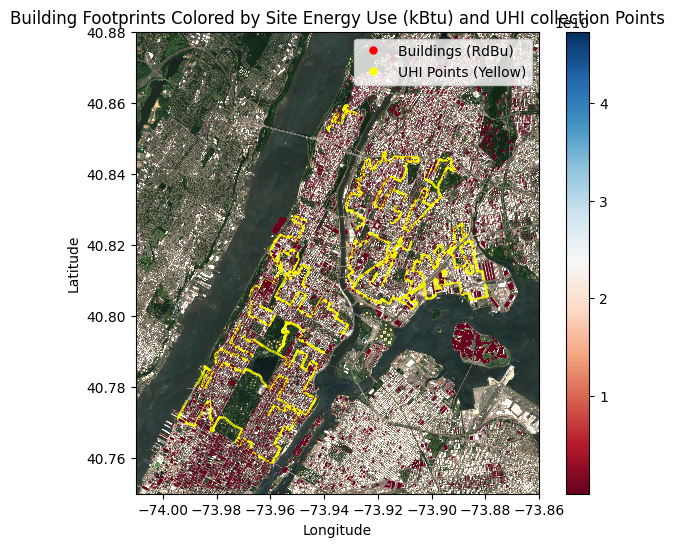

In [91]:
#csv path for target variable
csv_path = "data/Training_data_uhi_index.csv"

# Read the Excel file using pandas
uhi_df = pd.read_csv(csv_path)

# Create a geometry column from the Longitude and Latitude columns
uhi_df['geometry'] = uhi_df.apply(lambda row: Point(row['Longitude'], row['Latitude']), axis=1)

# Convert the DataFrame into a GeoDataFrame with EPSG:4326 (WGS84)
uhi_gdf = gpd.GeoDataFrame(uhi_df, geometry='geometry', crs='EPSG:4326')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the RGB composite as the base layer
median[["B04", "B03", "B02"]].to_array().plot.imshow(ax=ax, robust=True, vmin=0, vmax=2500)

# Plot the points, using UHI Index for the color mapping
uhi_gdf.plot(
    ax=ax,
    marker='.',
    color='yellow',
    legend=True,
    markersize=0.2
)

# Overlay the building footprints, coloring by "Site Energy Use (kBtu)"
# Using a colormap to visualize energy intensity
merged_gdf[merged_gdf["Site_Energy_Use_kBtu"] > 0].plot( ax=ax, cmap="RdBu", column="Site_Energy_Use_kBtu", legend=True)

# Create custom legend handles.
# UHI points handle: yellow dot.
uhi_handle = mlines.Line2D([], [], color='yellow', marker='.', linestyle='None', markersize=10, label='UHI Points (Yellow)')

# energy handle: sample a representative color from the colormap.
energy_handle = mlines.Line2D([], [], color='red', marker='.', linestyle='None', markersize=10, label='Buildings (RdBu)')

# Add the custom legend to the axis.
ax.legend(handles=[energy_handle, uhi_handle], loc='upper right')


# Add labels and title
ax.set_title("Building Footprints Colored by Site Energy Use (kBtu) and UHI collection Points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

Now, lets apply buffer zones to the energy data, since the building dataset was merged with the energy data it will be very easy to do so. This being because the building variables were already being used in the buffer zones so adding more building variables will be easy.

## Applying the Buffer Zones

We will use the same functions we used in our other generation notebook. Refer to those for more in detail explanations of what these functions are doing.

### Training Dataset

Apply the functions to each buffer radius and save the training dataset.

In [ ]:
energy_cols = [
    "Weather_Normalized_Site_EUI_kBtu_ft2",
    "Site_Energy_Use_kBtu",
    "Fuel_Oil_2_Use_kBtu",
    "Fuel_Oil_4_Use_kBtu",
    "Diesel_2_Use_kBtu",
    "District_Steam_Use_kBtu",
    "Natural_Gas_Use_kBtu",
    "Electricity_Use_Grid_Purchase_kBtu",
    "Electricity_Use_Generated_Onsite_Renewables_kWh",
    "Direct_GHG_Emissions_MetricTons_CO2e",
    "Percent_Electricity_Green_Power",
    "Water_Use_All_Sources_kgal"
]

In [ ]:
for buffer_radius in BUFFER_DISTANCES:
  # Generate the satellite image median.
  median = generate_median()

  # Generate the building geodataframe.
  buildings_gdf = generate_building_gdf()

  # Generate traffic data for UHI geodataframe.
  uhi_gdf = generate_traffic()

  # Read values into a series
  uhi = uhi_gdf['UHI Index'].values
  traffic_volume = uhi_gdf['traffic_volume'].values
  latitudes = uhi_gdf['Latitude'].values
  longitudes = uhi_gdf['Longitude'].values
  datetimes = uhi_gdf['datetime'].values

  # Apply Buffer Zone
  train_df = generate_buffer_dataset(
      latitudes, longitudes,
      buffer_radius, traffic_volume,
      median, buildings_gdf,
      UHI=uhi, datetimes=datetimes,
      energy_cols_to_buffer = energy_cols)

  # Add the weather data
  train_df = generate_weather_data(train_df)

  # remove cols we dont need
  cols = ['Latitude', 'Longitude', 'datetime']
  train_df.drop(cols, axis=1, inplace=True)

  # Save to csv file
  train_df.to_csv(f"{buffer_radius*2}m_buffer_dataset.csv", index=False)

### Training Dataset

In [ ]:
#csv path for target variable for testing dataset
test_csv = "data/Testing_data_uhi_index.csv"

# Generate traffic data for UHI geodataframe.
test_uhi_df = generate_traffic(uhi_csv_file="data/Testing_data_uhi_index.csv")

# Read values into a series
traffic_volume = test_uhi_df['traffic_volume'].values
latitudes = test_uhi_df['Latitude'].values
longitudes = test_uhi_df['Longitude'].values

for buffer_radius in BUFFER_DISTANCES:
  # Apply Buffer Zone
  test_df = generate_buffer_dataset(
      latitudes, longitudes,
      buffer_radius, traffic_volume,
      median, buildings_gdf)

  # Add the weather data
  test_df = generate_weather_data(test_df)

  # drop variables we dont need
  # NOTE: We need the lat and lon here, since they are required in the final submission
  cols = ['datetime', 'UHI']
  test_df.drop(cols, axis=1, inplace=True)

  # Save to csv file
  test_df.to_csv(f"{buffer_radius*2}m_buffer_test_dataset.csv", index=False)

## Final Training/Validation Datasets

Now, we have four new Training/Validation datasets that combined the following:

- **Target Dataset**:
  - Ground temperature data over New York City on July 24, 2021
- **Feature Datasets**:
  - European Sentinel-2 optical satellite data
  - Building Footprint Data with Additional Attributes
  - Automated Traffic Volume Counts
  - Detailed local weather dataset of the Bronx and Manhattan regions on 24 July 2021
  - Building Energy & Water Performance

These four new datasets have different sizes for their buffer zones (50m, 100m, 150m, & 300m) but the same variables. **They will be our version 2 of our Training/Validation/Testing dataset.**

**Variables**:
- **UHI** (Target Variable): (Temperature at a given location) / (Mean temperature for all locations). Reflects the variability of temperatures within our collected dataset and time collection window. As an example, a UHI index value of 1.0
suggests the local temperature is the same as the
mean temperature of all collected data points. UHI
index values above 1.0 are consistent with hotspots
above mean temperature values and UHI index values
below 1.0 are consistent with cooler locations in the
city.
- **NDVI**: The average Normalized Difference Vegetation Index (NDVI) of the buffer zone. NDVI is used to measure the "greenness" of vegetation and has a range of 0.0 to 1.0. Low values (0.0 to 0.25) reflect a lack of vegetation (bare soil, urban, water), middle values (0.25 to 0.6) reflect grasslands or croplands in their growing state, and high values (0.6 to 1.0) reflect dense vegetation such as trees or croplands at their peak vegetation state.
- **NDBI**: The average Normalized Difference Buildup Index (NDBI) of the buffer zone. NDBI is a ratio-based index to highlight built-up areas or areas of urbanization. Low values (below zero) reflect a lack of urbanization and are typical of water or vegetation. High values (above zero) reflect urbanization with the highest densities.
- **NDWI**: The average Normalized Difference Water Index (NDWI) of the buffer zone. NDWI is a ratio-based index to highlight areas with surface water. Higher values highlight areas of water and lower values highlight areas of non-water.
- **SI**: The average Shadow Index (SI) of the buffer zone. SI helps in identifying areas where shadows occur. Lower values indicate shadows. Higher values indicate illuminated areas or non-shadowed surfaces.
- **NDMI**: The average normalized difference moisture Index (NDMI) of the buffer zone. NDMI is used to determine vegetation water content and monitor droughts. Lower values of NDMI correspond to barren soil. Values around the middle generally correspond to water stress. High values represent high canopy without water stress.
- **NPCRI**: The average The Normalized Pigment Chlorophyll Ratio Index (NPCRI) of the buffer zone. NPCRI is a remote sensing index designed to estimate the chlorophyll content in vegetation. Chlorophyll is a key pigment in plants that is essential for photosynthesis, and its concentration is directly related to plant health and productivity. Being that photosynthesis reduces heat, this might be useful to determine plant productivity in reducing heat. Higher values indicate high chlorophyll content (healthy vegetation with strong photosynthetic activity).
Lower values indicate low chlorophyll content (stressed or unhealthy vegetation).
- **Coastal Aerosol**: The average Coastal aerosol of the buffer zone. Coastal aerosol refers to aerosol particles (tiny solid or liquid particles suspended in the atmosphere) that are found in or around coastal regions. These aerosols are typically composed of a variety of substances, including salt, dust, organic compounds, and pollutants. Coastal aerosols have a significant influence on local weather, climate, air quality, and ocean ecosystems.
- **Building Count**: The count of buildings in the buffer zone.
- **Total Building Area m2**: The total building area in the buffer zone.
- **Building Density**: The fraction of the buffer zone covered by buildings.
- **Building Height**: The average building height in the buffer zone (already normalize based on ground level).
- **Building Construction Year**: The average building construction year in the buffer zone (building materials differ from year built so this might be useful)
- **Ground Elevation**: The average ground elevation in the buffer zone.
- **Traffic Volume**: The automated traffic count found by using nearest interpolation to get the nearest traffic sensor to the UHI collection point. NOTE, buffer zones were not used here.
- **Air Temp at Surface [degC]**: The average air temperature recorded from 3:00 pm to 4:00 pm on July 24, 2021 at the closest weather station (either Bronx or Manhattan).
- **Relative Humidity [percent]**: The average Humidity recorded from 3:00 pm to 4:00 pm on July 24, 2021 at the closest weather station (either Bronx or Manhattan).
- **Avg Wind Speed [m/s]**: The average Wind Speed recorded from 3:00 pm to 4:00 pm on July 24, 2021 at the closest weather station (either Bronx or Manhattan).
- **Wind Direction [degrees]**: The average Wind Direction recorded from 3:00 pm to 4:00 pm on July 24, 2021 at the closest weather station (either Bronx or Manhattan).
- **Solar Flux [W/m^2]**: The average amount of solar energy that reached the ground recorded from 3:00 pm to 4:00 pm on July 24, 2021 at the closest weather station (either Bronx or Manhattan).
- **Weather_Normalized_Site_EUI_kBtu_ft2**: The average Weather Normalized Site EUI (kBtu/ft2) in the buffer zone. Weather Normalized Site EUI is the energy use the building would have consumed during 30-year average weather conditions. For example, if 2012 was a very hot year, then your Weather Normalized Site Energy may be lower than your Site Energy Use, because you would have used less energy if it had not been so hot.
- **Site_Energy_Use_kBtu**: The average Site Energy Use (kBtu) in the buffer zone. Site Energy Use is the annual amount of all the energy your property consumes on-site, regardless of the source. It includes energy purchased from the grid or in bulk (which are the amounts on utility bills), as well as renewable energy generated and consumed on-site such as from solar and wind (excess renewable energy generated on-site and sold to the utility is excluded from site energy use). Site Energy can be used to understand how the energy use for an individual property has changed over time.
- **Fuel_Oil_2_Use_kBtu**: The average Fuel Oil 2 Use (kBtu) in the buffer zone. Fuel Oil 2 Use is a summary of the annual consumption of an individual type of energy (e.g. electricity or natural gas).
- **Fuel_Oil_4_Use_kBtu**: The average Fuel Oil 4 Use (kBtu) in the buffer zone. Fuel Oil 4 Use is a summary of the annual consumption of an individual type of energy (e.g. electricity or natural gas).
- **Diesel_2_Use_kBtu**: The average Diesel 2 Use (kBtu) in the buffer zone. Diesel 2 Use is a summary of the annual consumption of an individual type of energy (e.g. electricity or natural gas).
- **District_Steam_Use_kBtu**: The average District Steam Use (kBtu) in the buffer zone. District Steam Use is a summary of the annual consumption of an individual type of energy (e.g. electricity or natural gas)
- **Natural_Gas_Use_kBtu**: The average Natural Gas Use (kBtu) in the buffer zone. Natural Gas Use is a summary of the annual consumption of an individual type of energy (e.g. electricity or natural gas)
- **Electricity_Use_Grid_Purchase_kBtu**: The average Electricity Use Grid Purchase (kBtu) in the buffer zone. Electricity Use Grid Purchase is a summary of the annual consumption of an individual type of energy (e.g. electricity or natural gas)
- **Electricity_Use_Generated_Onsite_Renewables_kWh**: The average Electricity Use Generated Onsite Renewables (kWh) in the buffer zone. Electricity Use Generated Onsite Renewables is a summary of the annual consumption of an individual type of energy (e.g. electricity or natural gas)
- **Direct_GHG_Emissions_MetricTons_CO2e**: The average Direct GHG Emissions (Metric Tons CO2e) in the buffer zone. Direct GHG Emissions are emissions associated with onsite fuel combustion (e.g. combustion of natural gas or fuel oil).
- **Percent_Electricity_Green_Power**: The average Percent Electricity Green Power in the buffer zone. Percent Electricity Green Power is the percent of electricity used was green power.
- **Water_Use_All_Sources_kgal**: The average Water Use (All Water Sources) (kgal) in the buffer zone. Water Use (All Water Source) is Sum of all water meters.

# Conclusion

Now we have more features to feed into our UHI models. Energy variables can help us see which Buildings are generating the most emissions.

# Reference

- New York City UHI Index
   - Description: Ground temperature data over New York City on July 24, 2021 (CSV format)
   - Contributors: Climate, Adaptation, Planning, Analytics (CAPA) Strategies
   - Data Host: Center for Open Science - https://www.cos.io
   - Terms of Use: https://github.com/CenterForOpenScience/cos.io/blob/master/TERMS_OF_USE.md
   - License: Apache 2.0 > https://github.com/CenterForOpenScience/cos.io/blob/master/LICENSE
- Satellite Data (Sentinel-2 Sample Output)
   - Description: Copernicus Sentinel-2 sample data from 2021 obtained from the Microsoft Planetary Computer (TIFF format)
   - Contributors: European Space Agency (ESA), Microsoft
   - Data Host: Microsoft Planetary Computer - https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a
   - Terms of Use: https://sentinel.esa.int/documents/247904/690755/Sentinel_Data_Legal_Notice
   - License: https://creativecommons.org/licenses/by-sa/3.0/igo/
- Building Footprint Data
   - Description: Building footprint polygons over the data challenge region of interest (KML format)
   - Contributors: Open Data Team at the NYC Office of Technology and Innovation (OTI)
- New York City Open Data Project
   - Data Host: https://data.cityofnewyork.us/Housing-Development/Building-Footprints/nqwf-w8eh
   - Terms of Use: https://www.nyc.gov/html/data/terms.html and https://www.nyc.gov/home/terms-of-use.page
   - License: https://github.com/CityOfNewYork/nyc-geo-metadata#Apache-2.0-1-ov-file
- Weather Data
   - Description: Detailed weather data collected every 5 minutes at two locations (Bronx and Manhattan). Includes surface air temperature (2-meters), relative humidity, average wind speed, wind direction, and solar flux.
   - Contributors: New York State Mesonet
   - Data Host: https://nysmesonet.org/
   - Terms of Use: https://nysmesonet.org/about/data
   - License: https://nysmesonet.org/documents/NYS_Mesonet_Data_Access_Policy.pdf
- Building Footprint Data with Additional Attributes
   - Description: Building footprints represent the full perimeter outline of each building as viewed from directly above. Additional attribute information maintained for each feature includes: Building Identification Number (BIN); Borough, Block, and Lot information(BBL); ground elevation at building base; roof height above ground elevation; construction year, and feature type.
   - Data Host: [NYC Open Data](https://data.cityofnewyork.us/City-Government/Building-Footprints/5zhs-2jue)
   - repo: https://github.com/CityOfNewYork/nyc-geo-metadata/blob/main/Metadata/Metadata_BuildingFootprints.md
   - License: https://github.com/CityOfNewYork/nyc-geo-metadata/blob/main/LICENSE
- Automated Traffic Volume Counts
   - Description: New York City Department of Transportation (NYC DOT) uses Automated Traffic Recorders (ATR) to collect traffic sample volume counts at bridge crossings and roadways.These counts do not cover the entire year, and the number of days counted per location may vary from year to year.
   - Data Host: [NYC Open Data](https://data.cityofnewyork.us/Transportation/Automated-Traffic-Volume-Counts/7ym2-wayt)
- NYC Energy & Water Performance
   - Description: Local Law 84 of 2009 (LL84) requires annual energy and water benchmarking data to be submitted by owners of buildings with more than 50,000 square feet. This data is collected via the Environmental Protection Agency's (EPA) Portfolio Manager website. Each property is identified by it's EPA assigned property ID, and can contain one or more tax lots identified by one or more BBLs (Borough, Block, Lot) or one or more buildings identified by one or more building identification numbers (BIN)
   - Data Host: [NYC Open Data](https://data.cityofnewyork.us/Environment/NYC-Building-Energy-and-Water-Data-Disclosure-for-/5zyy-y8am/about_data)